In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rasterio as rio
import rioxarray as rxr
import matplotlib.pyplot as plt
from glob import glob
import re

from reportlab.lib import colors
from reportlab.lib.pagesizes import letter, landscape
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import Paragraph, Spacer

from datetime import datetime


In [3]:
## set date
date = "20250408"
#date = datetime.today().strftime('%Y%m%d') # get today's date

formatted_date = datetime.strptime(date, "%Y%m%d").strftime("%Y-%m-%d")

In [4]:
## Move functions to a separate file

## function for calculating swe statistics for polygons
def swe_stat_calc(raster, shapefile_gdf):
    """
    Calculates snow water equivalent mean, median, and volume for each 
    polygon in a shapefile and returns it as a dataframe.

    Parameters:
    raster (xarray.DataArray): An xarray object with SWE raster data. Units must be in inches.
    shapefile_gdf (geopandas.GeoDataFrame): A GeoDataFrame with shapefile data.

    Returns:
    pandas.DataFrame: A DataFrame with one row for each polygon in shapefile and columns
                        for median, mean, and total swe volume. Mean and median units are
                        in inches and volume units are acre feet.
    """

    cols_swe = ['name', 'Median SWE (in.)', 'Mean SWE (in.)', 
                'Estimated Volume (af)'] #output column names
    swe_df = [] #empty list for polygon stats

    ## loop through each polygon in shapefile and append statistics to swe_df list
    for idx, basin in shapefile_gdf.iterrows():
        swe_basin = raster.rio.clip([basin.geometry])
        
        '''
        ## plot clipped polygon
        f, ax = plt.subplots()
        swe_basin.plot(cmap="Blues",
                        ax=ax)
        cbar = ax.collections[-1].colorbar
        cbar.set_label('SWE [in]', fontsize=16, labelpad=14)
        cbar.ax.tick_params(labelsize=12)
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
        ax.set_xlabel('Easting [m]')
        ax.set_ylabel('Northing [m]')
        ax.set_title('SWE Overview ' + basin['Name'])
        plt.show()'
        '''
        
        
        swe_median = np.nanmedian(swe_basin) # median swe for basin
        swe_mean = np.nanmean(swe_basin) # mean swe for basin
        swe_sum_inches = np.nansum(swe_basin) # swe sum for basin

        ## get pixel area in feet
        pixel_size_x, pixel_size_y = swe_basin.rio.resolution()
        pixel_area = abs((pixel_size_x*3.28084) * (pixel_size_y*3.28084))
        
        swe_vol_cuft = (swe_sum_inches / 12) * pixel_area # volume in cubic feet
        swe_vol_af = np.float32(swe_vol_cuft / 43560) # volume in acre feet

        ## append values to list
        swe_df.append([basin['Name'], swe_median, 
                    swe_mean, swe_vol_af,])

    ## convert list to dataframe
    swe_df_table = pd.DataFrame(swe_df, columns=cols_swe)
    return(swe_df_table)

## function for calculating swe volume difference since last report
## FIX ME!
## Add condition to check if previous report exists. Only necessary for first report per year
def swe_diff_calc(report_date, table, table_num):
    """
    Calculates snow water equivalent volume difference since last report and appends it 
    to the input table.

    Parameters:
    report_date (str): An string object of today's date.
    table (pandas.DataFrame): A DataFrame of report tables 1, 2, or 3.
    table_num (str): An string with values between 1 and 3 specifying the table number for file naming. 

    Returns:
    pandas.DataFrame: A DataFrame with SWE volume difference since last report appended.
    """

    ## get date of last report
    date_pattern = re.compile(r"(\d{8})") # date format in filename
    report_files = glob(f'../reports/csvs/table{table_num}*')
    report_files = [file for file in report_files if report_date not in file]
    filename_lastreport = max(
        report_files,
        key=lambda f: datetime.strptime(date_pattern.search(f).group(1), "%Y%m%d")
    )
    date_lastreport = re.search(date_pattern, filename_lastreport).group(1)
    date_lastreport_formatted = datetime.strptime(date_lastreport, "%Y%m%d").strftime("%Y-%m-%d")

    ## read csv for last report
    table_lastreport = pd.read_csv(filename_lastreport)
    table_current = table.loc[:, :'Estimated Volume (af)']

    ## calculate volume difference since laste report
    vol_diff = np.float32(table['Estimated Volume (af)'] - table_lastreport['Estimated Volume (af)'])

    ## new column name
    col_name_diff = f'Volume Change since {date_lastreport_formatted} (af)'
    table_current[col_name_diff] = vol_diff

    ## save to csv before converting floats to strings
    table_current.to_csv(f'../reports/csvs/table{table_num}_{report_date}.csv', 
                         encoding='utf-8', index=False, header=True)
    
    ## round column values and convert to strings with commas
    cols_round = ['Median SWE (in.)', 'Mean SWE (in.)']
    table_current[cols_round] = table_current[cols_round].map(lambda x: f'{x:,.1f}' if isinstance(x, (int, float)) else x)
    table_current['Estimated Volume (af)'] = table_current['Estimated Volume (af)'].map(lambda x: f'{x:,.0f}' if isinstance(x, (int, float)) else x)
    if col_name_diff in table_current.columns:
        table_current[col_name_diff] = table_current[col_name_diff].map(lambda x: f'{x:,.0f}' if isinstance(x, (int, float)) else x)
    
    return(table_current)

## Create function to write tables to pdf
    

## Read raster and shapefile data

In [5]:
# Read/clip data
snodas_file = "../data/SNODAS/SNODAS_SWE_" + date + ".tif"
snodas = rxr.open_rasterio(snodas_file).sel(band=1).reset_coords('band', drop=True)
snodas_utm = snodas.rio.reproject('epsg:26913', resolution=1000)
huc6 = gpd.read_file('../data/Shapefiles/WBDHU6_RG/WBDHU6_RG.shp').to_crs('epsg:26913')
huc8 = gpd.read_file('../data/Shapefiles/WBDHU8_RG/WBDHU8_RG.shp').to_crs('epsg:26913')
huc8 = huc8.drop(huc8.index[72]) #remove Rio Salado polygon in Mexico
ose = gpd.read_file('../data/Shapefiles/OSE_Basin_Designations/SubBasins_Dissolve.shp').to_crs('epsg:26913')

In [6]:
## filter data to polygons of interest
huc6_polys = ['Rio Grande Headwaters', 'Upper Rio Grande',
       'Rio Grande-Elephant Butte']
huc6 = huc6[huc6['Name'].isin(huc6_polys)]

huc8['Name'].unique()
huc8_polys = ['Rio Grande Headwaters', 'Alamosa-Trinchera',
              'San Luis', 'Saguache',
              'Conejos', 'Upper Rio Grande',
              'Rio Chama', 'Rio Grande-Santa Fe',
              'Jemez', 'Rio Grande-Albuquerque',
              'Arroyo Chico', 'North Plains',
              'Rio San Jose', 'Plains of San Agustin',
              'Rio Salado', 'Jornada Del Muerto',
              'Elephant Butte Reservoir', 'Rio Puerco']
huc8 = huc8[huc8['Name'].isin(huc8_polys)]

## sort by polygon order
huc8 = huc8.set_index('Name', drop = False)
huc8 = huc8.reindex(huc8_polys)

## filter ose polygons
ose = ose.loc[ose['SubBasin'] != 'San Juan River Basin']
ose = ose.rename(columns={'SubBasin': 'Name'}) 
ose = ose.replace({'Name' : {'JemezRiver Basin' : 'Jemez', 
                             'Rio Chama River Basin' : 'Rio Chama', 
                             'Sangre De Cristo Mountain Range Basins' : 'Sangre de Cristo',
                            'Upper Rio Grande Basin' : 'Upper Rio Grande' }})

## confirm CRS are all equal
ose.crs == huc8.crs == huc6.crs == snodas.rio.crs

## add huc6 basin and region columns to huc8 shapefile for table 1
## huc6 basins
huc6_basin = np.array(['Rio Grande Headwaters', 'Upper Rio Grande', 
                       'Rio Grande-Elephant Butte'])
huc6_basin = np.repeat(huc6_basin, [5, 2, 11], axis=0)

## region
region = np.repeat('Rio Grande', [18], axis = 0)

huc8['HUC6 Basin'] = huc6_basin
huc8['Region'] = region
huc8.head()
huc6.head()
ose.head()

,Name,Shape_Leng,Shape_Area,geometry
0,Jemez,3.398059e+05,4.163069e+09,"POLYGON ((370349.049 3987334.158, 370358.675 3..."
1,Rio Chama,5.521299e+05,1.268620e+10,"POLYGON ((397422.42 4071697.147, 397492.608 40..."
3,Sangre de Cristo,1.453554e+06,3.012485e+10,"POLYGON ((409807.589 4256822.09, 409962.715 42..."
4,Upper Rio Grande,1.114530e+06,1.436838e+10,"MULTIPOLYGON (((369074.948 4137353.159, 369155..."


## Clip SNODAS to HUC8 and plot

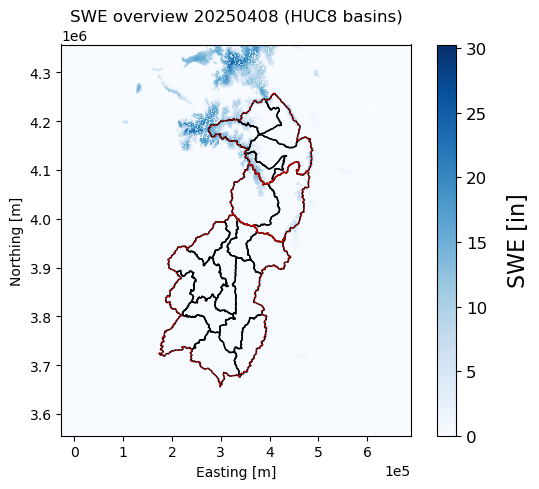

In [7]:
# clip SWE data to HUC8 bounds
bounds = huc8.total_bounds
xpad = 200000
ypad = 100000
bounds_padded = [bounds[0]-xpad, bounds[1]-ypad, bounds[2]+xpad, bounds[3]+ypad]
snodas_clip = snodas_utm.where(snodas_utm>=0).rio.clip_box(*bounds_padded) / 1000 * 3.2808 * 12 # convert to inches

# Plot
fig, ax = plt.subplots(figsize=(6,5))
snodas_clip.plot(ax=ax, cmap='Blues')
cbar = ax.collections[-1].colorbar
cbar.set_label('SWE [in]', fontsize=16, labelpad=14)
cbar.ax.tick_params(labelsize=12)
huc8.plot(ax=ax, facecolor='none', edgecolor='k')
huc6.plot(ax=ax, facecolor='none', edgecolor = 'red', linestyle=":")
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_title('SWE overview ' + date + ' (HUC8 basins)')
plt.tight_layout()

## Table 1

In [8]:
## huc8 stats calculation
huc8_stats = swe_stat_calc(snodas_clip, huc8)
huc8_stats = huc8_stats.rename(columns={'name': 'HUC8 Subbasin'}) 
huc8_stats['HUC6 Basin'] = huc6_basin

## huc6 stats calculation
huc6_stats = swe_stat_calc(snodas_clip, huc6)
huc6_stats = huc6_stats.rename(columns={'name': 'HUC6 Basin'})
huc6_stats['HUC8 Subbasin'] = np.repeat('Total', [3], axis=0)

## concatenate, select columns
table1 = pd.concat([huc8_stats, huc6_stats], ignore_index=True)
table1 = table1[['HUC6 Basin', 'HUC8 Subbasin', 'Median SWE (in.)', # reorder columns
                 'Mean SWE (in.)', 'Estimated Volume (af)']]


## FIX ME!
## temporary fix to reoder rows, needs to be changed ##
table1 = table1.reindex([0, 1, 2, 3, 4, 18,
                         5, 6, 19,
                         7, 8, 9, 10, 11, 12, 
                         13, 14, 15, 16, 17, 20]).reset_index().drop(columns= ['index'])

## FIX ME! ##
## Add function call here to calcultion percent total volume per subbasin

## calculate volume difference since last report
table1 = swe_diff_calc(date, table1, "1")

## remove duplicate HUC6 labels
table1['HUC6 Basin'] = table1.groupby('HUC6 Basin')['HUC6 Basin'].transform(lambda x: x.where(x.index == x.index[0], ""))


## export to pdf
'''
table1_html = table1.to_html(index=False)
table1_out = "../reports/table1_" + date + ".pdf"

HTML(string = table1_html).write_pdf(table1_out)
'''

# PDF filename
pdf_filename = "../reports/reportlab_table1_" + date + ".pdf"

# Create empty PDF
doc = SimpleDocTemplate(pdf_filename, pagesize = letter)
elements = []

# Convert dataframe to list of lists (including column headers)
columns = table1.columns.tolist()
columns[-1] = columns[-1].replace("Change", "Change\n")
table_data = [columns] + table1.values.tolist()

# Create Table
col_widths = [100] * len(table1.columns) # adjust column width
table = Table(table_data, colWidths = col_widths)

# Add style to Table
style = TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),  # Header background
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),  # Header text color
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),  # Align all text to center
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),  # Header font
    ('FONTSIZE', (0, 0), (-1, 0), 8),  # Header font size (default 10)
    ('FONTSIZE', (0, 1), (-1, -1), 8),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 8),  # Padding for header
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.lightgrey]),  # Row background color
    ('GRID', (0, 0), (-1, -1), 1, colors.black)  # Grid lines
])

table.setStyle(style)

# Set pdf title
styles = getSampleStyleSheet()
title = Paragraph(f'Table 1. Estimated SWE by Basin and Subbasin for {formatted_date}', styles["Title"])

# Add title
elements.append(title)

# Add space between text and table
elements.append(Spacer(1, 12))

# Add table to PDF
elements.append(table)

# Build PDF
doc.build(elements)

# print pandas dataframe
table1.style.hide()


HUC6 Basin,HUC8 Subbasin,Median SWE (in.),Mean SWE (in.),Estimated Volume (af),Volume Change since 2025-04-01 (af)
Rio Grande Headwaters,Rio Grande Headwaters,6.4,6.3,"460,261","54,706"
,Alamosa-Trinchera,0.0,0.7,"96,407","27,491"
,San Luis,0.0,0.6,"53,339","10,890"
,Saguache,0.0,1.4,"100,714","20,221"
,Conejos,0.5,3.9,"161,191","19,900"
,Total,0.0,2.1,"871,912","133,209"
Upper Rio Grande,Upper Rio Grande,0.0,0.6,"95,903","20,696"
,Rio Chama,0.0,1.0,"164,623","15,711"
,Total,0.0,0.8,"260,526","36,408"
Rio Grande-Elephant Butte,Rio Grande-Santa Fe,0.0,0.0,"4,122","3,702"


In [9]:
table1.columns.tolist()

['HUC6 Basin',
 'HUC8 Subbasin',
 'Median SWE (in.)',
 'Mean SWE (in.)',
 'Estimated Volume (af)',
 'Volume Change since 2025-04-01 (af)']

## Table 2

In [10]:
huc8_ose_polys = ['Rio Grande Headwaters', 'Saguache',
                  'Conejos', 'San Luis',
                  'Alamosa-Trinchera', 'Upper Rio Grande']
huc8_ose = huc8[huc8['Name'].isin(huc8_ose_polys)]

## sort by polygon order
huc8_ose = huc8_ose.set_index('Name', drop = False)
huc8_ose = huc8_ose.reindex(huc8_ose_polys)

## add ose basin column
ose_grouping = np.array(['Upper Rio Grande', 
                       'Sangre de Cristo'])
ose_grouping = np.repeat(ose_grouping, [3, 3], axis=0)

huc8_ose['OSE Grouping'] = ose_grouping

## create table
huc8_ose_stats = swe_stat_calc(snodas_clip, huc8_ose)
huc8_ose_stats = huc8_ose_stats.rename(columns={'name': 'HUC8 Subbasin'}) 
huc8_ose_stats['OSE Grouping'] = ose_grouping


ose_stats = swe_stat_calc(snodas_clip, ose)
ose_stats = ose_stats.rename(columns={'name': 'OSE Grouping'})
ose_stats['HUC8 Subbasin'] = np.repeat('Total', [4], axis=0)

#huc6_stats
table2 = pd.concat([huc8_ose_stats, ose_stats], ignore_index=True)
table2 = table2[['OSE Grouping', 'HUC8 Subbasin', 'Median SWE (in.)', 
                 'Mean SWE (in.)', 'Estimated Volume (af)']]

## FIX ME!
## temporary fix to reoder rows, needs to be changed ##
table2 = table2.reindex([0, 1, 2, 9,
                         3, 4, 5, 8,
                         7, 6]).reset_index().drop(columns= ['index'])

## calculate volume difference since last report
table2 = swe_diff_calc(date, table2, "2")

## remove duplicate OSE labels
table2['OSE Grouping'] = table2.groupby('OSE Grouping')['OSE Grouping'].transform(lambda x: x.where(x.index == x.index[0], ""))

## export to pdf
'''
table2_html = table2._repr_html_()
table2_out = "../reports/table2_" + date + ".pdf"

HTML(string = table2_html).write_pdf(table2_out)'
'''
# PDF filename
pdf_filename = "../reports/reportlab_table2_" + date + ".pdf"

# Create empty PDF document
doc = SimpleDocTemplate(pdf_filename, pagesize = letter)
elements = []

# Convert dataframe to list of lists (including column headers)
columns = table2.columns.tolist()
columns[-1] = columns[-1].replace("Change", "Change\n")
table_data = [columns] + table2.values.tolist()

# Create Table
col_widths = [90] * len(table2.columns) # adjust column width
table = Table(table_data, colWidths = col_widths)

# Add style to Table
style = TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),  # Header background
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),  # Header text color
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),  # Align all text to center
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),  # Header font
    ('FONTSIZE', (0, 0), (-1, 0), 8),  # Header font size (default 10)
    ('FONTSIZE', (0, 1), (-1, -1), 8),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 8),  # Padding for header
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.lightgrey]),  # Row background color
    ('GRID', (0, 0), (-1, -1), 1, colors.black)  # Grid lines
])

table.setStyle(style)

# Set pdf title
styles = getSampleStyleSheet()
title = Paragraph(f'Table 2. Estimated SWE by OSE Subbasin Groupings for {formatted_date}', styles["Title"])

# Add title
elements.append(title)

# Add space between text and table
elements.append(Spacer(1, 12))

# Add table to PDF
elements.append(table)

# Build PDF
doc.build(elements)

# print pandas dataframe
table2.style.hide()

OSE Grouping,HUC8 Subbasin,Median SWE (in.),Mean SWE (in.),Estimated Volume (af),Volume Change since 2025-04-01 (af)
Upper Rio Grande,Rio Grande Headwaters,6.4,6.3,"460,261","54,706"
,Saguache,0.0,1.4,"100,714","20,221"
,Conejos,0.5,3.9,"161,191","19,900"
,Total,0.8,3.9,"720,339","94,384"
Sangre de Cristo,San Luis,0.0,0.6,"53,339","10,890"
,Alamosa-Trinchera,0.0,0.7,"96,407","27,491"
,Upper Rio Grande,0.0,0.6,"95,903","20,696"
,Total,0.0,0.6,"244,575","59,104"
Rio Chama,Total,0.0,1.0,"165,743","15,838"
Jemez,Total,0.0,0.3,"14,337","12,736"


## Table 3 (Elevation bands)

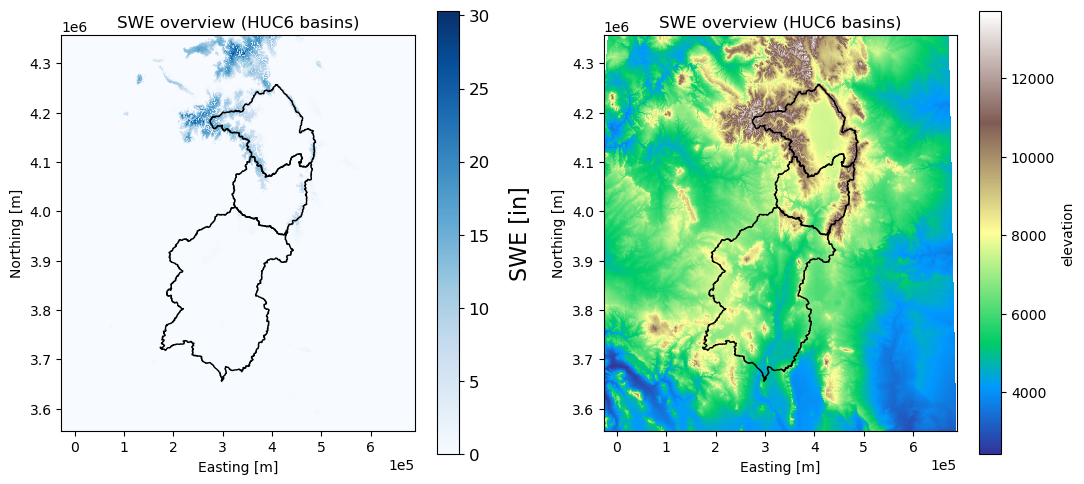

In [11]:
## read DEM 
dem = rxr.open_rasterio('../data/dem.tif').sel(band=1).reset_coords('band', drop=True)
dem = dem.where(dem>=0).rio.reproject_match(snodas_clip)

## combine swe and dem arrays
swe_ds = xr.Dataset()
swe_ds['swe'] = snodas_clip
swe_ds['elevation'] = dem

## plot
fig, ax = plt.subplots(1, 2, figsize=(11,5))
swe_ds.swe.plot(ax=ax[0], cmap='Blues')
swe_ds.elevation.plot(ax=ax[1], cmap='terrain')
cbar = ax[0].collections[-1].colorbar
cbar.set_label('SWE [in]', fontsize=16, labelpad=14)
cbar.ax.tick_params(labelsize=12)
huc6.plot(ax=ax[0], facecolor='none', edgecolor='k')
huc6.plot(ax=ax[1], facecolor='none', edgecolor='k')
for axx in ax.flatten():
    axx.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) 
    axx.set_xlabel('Easting [m]')
    axx.set_ylabel('Northing [m]')
    axx.set_title('SWE overview (HUC6 basins)')
plt.tight_layout()

In [12]:
## should bands be minimum to max elevation per basin or just those with snow

## get pixel area in feet
pixel_size_x, pixel_size_y = swe_ds.rio.resolution()
pixel_area = abs((pixel_size_x*3.28084) * (pixel_size_y*3.28084))
        

cols_swe_elev = ['HUC6 Basin', 'HUC8 Subbasin', 'Elevation Band (ft.)',
                 'Median SWE (in.)', 'Mean SWE (in.)', 
                 'Estimated Volume (af)'] #output column names
swe_elev_df = [] #empty list for polygon stats

for idx, basin in huc8.iterrows():
    swe_basin = swe_ds.rio.clip([basin.geometry])
    '''
    f, ax = plt.subplots()
    swe_basin.elevation.plot(cmap="terrain",
                            ax=ax)
    plt.show()
    '''

    ## get min and max elevation for basin
    elev_min = np.floor(float(np.nanmin(swe_basin.elevation)) / 1000) * 1000
    elev_max = np.ceil(float(np.nanmax(swe_basin.elevation)) / 1000) * 1000
    elev_bands = np.arange(elev_min, elev_max, 1000) # band height 1000 ft

    ## loop through elevation bands and calculate statistics
    for i in range(len(elev_bands)):
        elev_mask = (swe_basin['elevation'] >= elev_bands[i]) * (swe_basin['elevation'] < elev_bands[i] + 1000)
        swe_sum_inches = float(swe_basin['swe'].where(elev_mask).sum()) # sum swe at mask
        swe_vol_cuft = (swe_sum_inches / 12) * pixel_area # volume in cubic feet
        swe_vol_af = swe_vol_cuft / 43560 # volume in acre feet

        ## swe median and mean at mask
        swe_median = float(swe_basin['swe'].where(elev_mask).median())
        swe_mean = float(swe_basin['swe'].where(elev_mask).mean())

        band = str(int(elev_bands[i])) + '-' + str(int(elev_bands[i] + 1000)) + "\'"

        ## append values to list
        swe_elev_df.append([basin['HUC6 Basin'], basin['Name'], band, 
                    swe_median, swe_mean, swe_vol_af,])

## convert list to dataframe
table3 = pd.DataFrame(swe_elev_df, columns=cols_swe_elev)

## calculate volume difference since last report
table3 = swe_diff_calc(date, table3, "3")

## remov duplicate HUC6 and HUC8 labels
table3['HUC6 Basin'] = table3.groupby('HUC6 Basin')['HUC6 Basin'].transform(lambda x: x.where(x.index == x.index[0], ""))
table3['HUC8 Subbasin'] = table3.groupby('HUC8 Subbasin')['HUC8 Subbasin'].transform(lambda x: x.where(x.index == x.index[0], ""))

## export to pdf
'''
table3_html = table3._repr_html_()

table3_out = "../reports/table3_" + date + ".pdf"

HTML(string = table3_html).write_pdf(table3_out)
#pisa.CreatePDF(table3_html, table3_out)
'''

# PDF filename
pdf_filename = "../reports/reportlab_table3_" + date + ".pdf"

# Create empty PDF document
doc = SimpleDocTemplate(pdf_filename, pagesize = landscape(letter))
elements = []

# Convert dataframe to list of lists (including column headers)
columns = table3.columns.tolist()
columns[-1] = columns[-1].replace("Change", "Change\n")
table_data = [columns] + table3.values.tolist()

# Create Table
col_widths = [100] * len(table3.columns) # adjust column width
table = Table(table_data, colWidths = col_widths)

# Add style to Table
style = TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),  # Header background
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),  # Header text color
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),  # Align all text to center
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),  # Header font
    ('FONTSIZE', (0, 0), (-1, 0), 8),  # Header font size (default 10)
    ('FONTSIZE', (0, 1), (-1, -1), 8),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 8),  # Padding for header
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.lightgrey]),  # Row background color
    ('GRID', (0, 0), (-1, -1), 1, colors.black)  # Grid lines
])

table.setStyle(style)

# Table title
styles = getSampleStyleSheet()
title = Paragraph(f'Table 3. Estimated SWE by Basin and Elevation Band for {formatted_date}', styles["Title"])

# Add title before table
elements.append(title)

# Add space between text and table
elements.append(Spacer(1, 12))

# Add table to PDF
elements.append(table)

# Build PDF
doc.build(elements)

# print pandas dataframe
pd.set_option("display.max_rows", None, "display.max_columns", None) # no limit on max rows or columns for printing
table3.style.hide()



HUC6 Basin,HUC8 Subbasin,Elevation Band (ft.),Median SWE (in.),Mean SWE (in.),Estimated Volume (af),Volume Change since 2025-04-01 (af)
Rio Grande Headwaters,Rio Grande Headwaters,7000-8000',0.0,0.0,0,0
,,8000-9000',0.0,0.0,441,441
,,9000-10000',0.4,1.1,"15,349","5,484"
,,10000-11000',6.5,6.6,"144,425","19,306"
,,11000-12000',10.6,10.5,"229,149","23,377"
,,12000-13000',12.2,11.7,"69,875","5,980"
,,13000-14000',10.6,8.3,"1,021",119
,Alamosa-Trinchera,7000-8000',0.0,0.0,0,0
,,8000-9000',0.0,0.0,537,537
,,9000-10000',0.3,0.5,"10,799","8,499"


## Elevation bar plot - Elevation on y-axis

In [13]:
'''
table3 = pd.read_csv(f'../reports/csvs/table3_{date}.csv')
huc6_unique = table3['HUC6 Basin'].unique()

for i in range(len(huc6_unique)):
    huc6_id = huc6_unique[i]
    table3_huc6 = table3[table3['HUC6 Basin'] == huc6_id]

    # Get elevation bands and basins
    elevation_bands = table3_huc6['Elevation Band (ft.)'].unique()
    elevation_bands = sorted(elevation_bands, key=lambda x: int(x.split('-')[0]))
    basins = table3_huc6['HUC8 Subbasin'].unique()

    ## add empty elevation bands for each polygon
    all_combinations = pd.MultiIndex.from_product([basins, elevation_bands],
                                                names=['HUC8 Subbasin', 'Elevation Band (ft.)'])
    table3_huc6 = table3_huc6.set_index(['HUC8 Subbasin', 'Elevation Band (ft.)']).reindex(all_combinations).reset_index()

    y = np.arange(len(elevation_bands)) * 1  # position for grouped bars
    height = 0.1  # thickness of each bar

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))

    for i, basin in enumerate(basins):
        basin_data = table3_huc6[table3_huc6['HUC8 Subbasin'] == basin].set_index('Elevation Band (ft.)')
        values = basin_data.reindex(elevation_bands)['Estimated Volume (af)'].fillna(0)
        ax.barh(y + height * i, values, height=height, label=basin)

    ## center y ticks under group
    group_offset = height * (len(basins) / 2 - 0.5)
    ax.set_yticks(y + group_offset)
    ax.set_yticklabels(elevation_bands)

    ## flip x and y axis
    #ax.invert_yaxis()

    # Labels and title
    ax.set_ylabel('Elevation Band (ft.)')
    ax.set_xlabel('SWE Volume (af)')
    ax.set_title(f'{huc6_id} SWE by Subbasin and Elevation Band')
    ax.legend(title='HUC8 Subbasin')

    #plt.tight_layout()
    plt.show()
'''

"\ntable3 = pd.read_csv(f'../reports/csvs/table3_{date}.csv')\nhuc6_unique = table3['HUC6 Basin'].unique()\n\nfor i in range(len(huc6_unique)):\n    huc6_id = huc6_unique[i]\n    table3_huc6 = table3[table3['HUC6 Basin'] == huc6_id]\n\n    # Get elevation bands and basins\n    elevation_bands = table3_huc6['Elevation Band (ft.)'].unique()\n    elevation_bands = sorted(elevation_bands, key=lambda x: int(x.split('-')[0]))\n    basins = table3_huc6['HUC8 Subbasin'].unique()\n\n    ## add empty elevation bands for each polygon\n    all_combinations = pd.MultiIndex.from_product([basins, elevation_bands],\n                                                names=['HUC8 Subbasin', 'Elevation Band (ft.)'])\n    table3_huc6 = table3_huc6.set_index(['HUC8 Subbasin', 'Elevation Band (ft.)']).reindex(all_combinations).reset_index()\n\n    y = np.arange(len(elevation_bands)) * 1  # position for grouped bars\n    height = 0.1  # thickness of each bar\n\n    # Plot\n    fig, ax = plt.subplots(figsize=(8

## Elevation Bar plot - HUC8 Subbasin on y-axis

[]


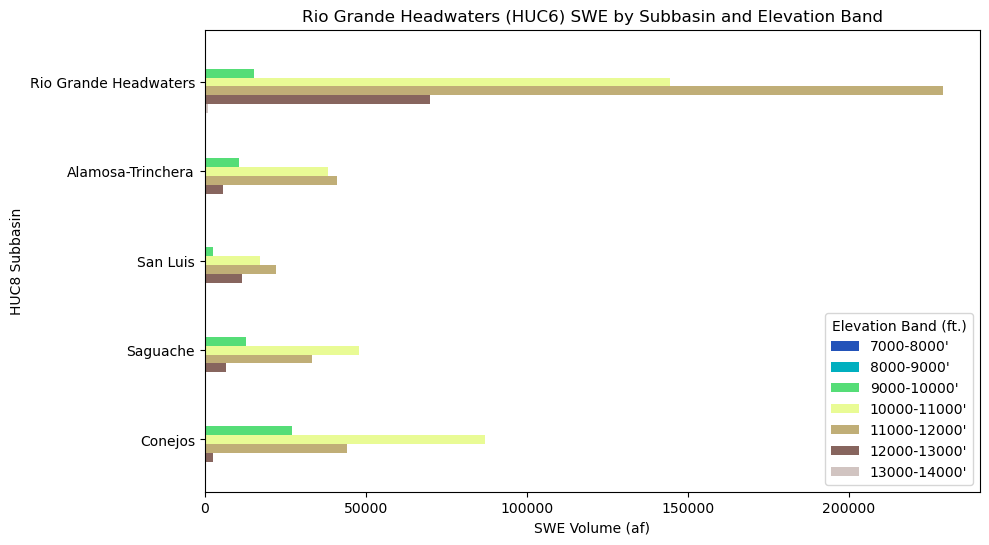

[]


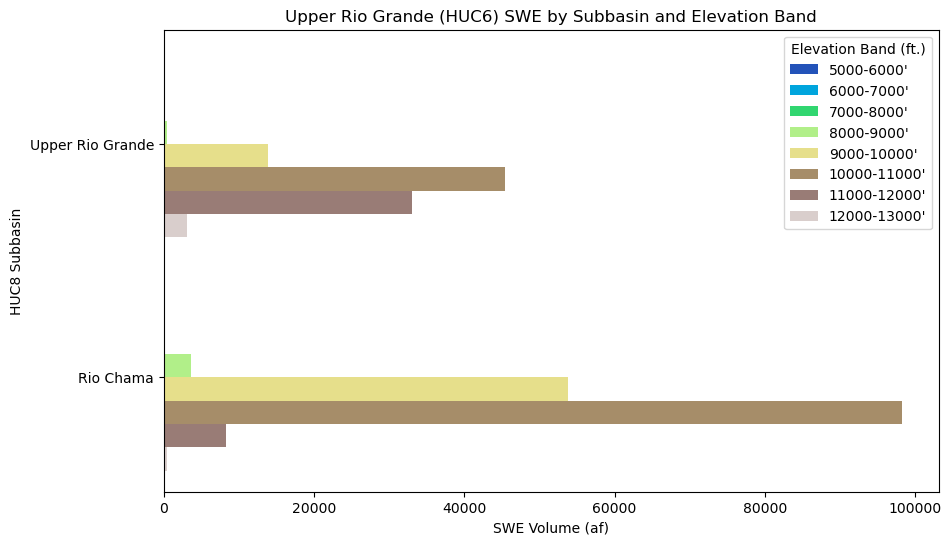

['Jornada Del Muerto']


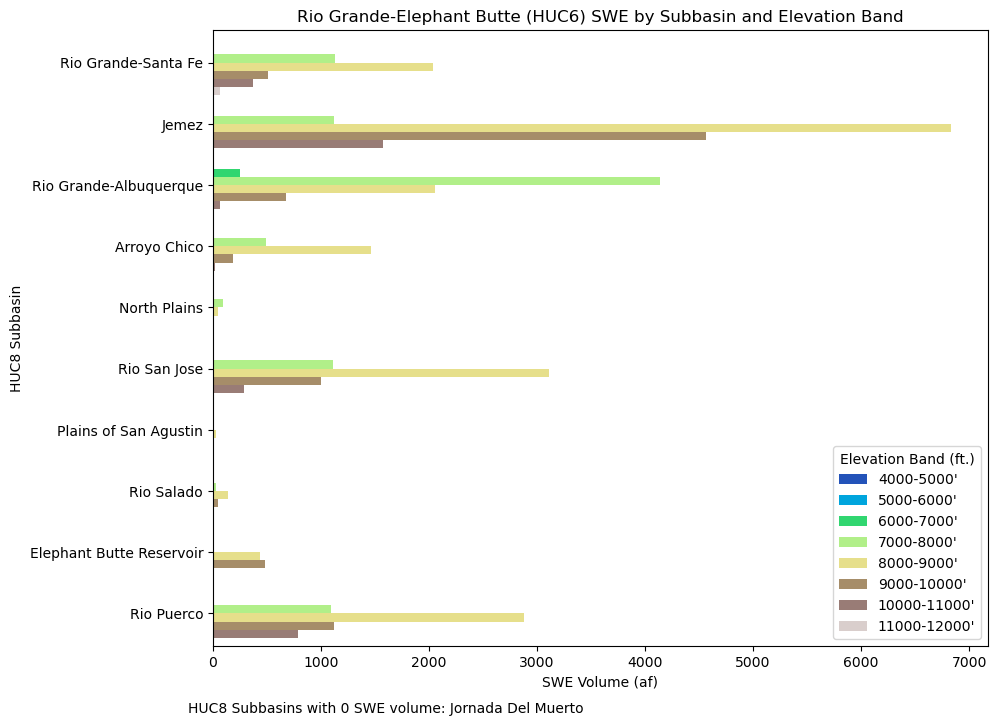

In [37]:
table3 = pd.read_csv(f'../reports/csvs/table3_{date}.csv')
#table3 = pd.read_csv(f'../reports/csvs/table3_{20250401}.csv') # testing day with low SWE
huc6_unique = table3['HUC6 Basin'].unique()

for i in range(len(huc6_unique)):
    huc6_id = huc6_unique[i]
    table3_huc6 = table3[table3['HUC6 Basin'] == huc6_id]    
    elevation_bands = table3_huc6['Elevation Band (ft.)'].unique()
    elevation_bands = sorted(elevation_bands, key=lambda x: int(x.split('-')[0]))
    basins = table3_huc6['HUC8 Subbasin'].unique()

    ## get list of huc8 subbasins with 0 swe volume
    huc8_totals = table3_huc6.groupby(['HUC8 Subbasin'], sort = False)['Estimated Volume (af)'].sum()
    huc8_zero_volume = huc8_totals.loc[huc8_totals == 0].index.tolist()
    print(huc8_zero_volume)

    ## remove basins with zero volume from plots
    basins = [i for i in basins if i not in huc8_zero_volume]

    ## add empty elevation bands for each polygon using multiindex
    all_combinations = pd.MultiIndex.from_product([basins, elevation_bands],
                                                names=['HUC8 Subbasin', "Elevation Band (ft.)"])
    table3_huc6 = table3_huc6.set_index(['HUC8 Subbasin', "Elevation Band (ft.)"]).reindex(all_combinations).reset_index()

    ## set y-axis positions for subbasin groups
    
    if huc6_id == 'Rio Grande-Elephant Butte':    
        y = np.arange(len(basins)) * 1.5 ## vertical spacing betweeng groups
        height = 0.2  # bar thickness
    else:
        y = np.arange(len(basins)) * 1
        height = 0.1  # bar thickness    

    # Plot
    if huc6_id == "Rio Grande-Elephant Butte":
        fig, ax = plt.subplots(figsize=(10, 8))
    else:    
        fig, ax = plt.subplots(figsize=(10, 6))
    

    colors = [plt.get_cmap('terrain')(i / len(elevation_bands) + 0.05) for i in range(len(elevation_bands))]
    #print(colors)
    #colors = plt.get_cmap('terrain')(np.linspace(0, 1, len(elevation_bands)))
    for i, band in enumerate(elevation_bands):
        band_data = table3_huc6[table3_huc6['Elevation Band (ft.)'] == band].set_index('HUC8 Subbasin')
        values = band_data.reindex(basins)['Estimated Volume (af)'].fillna(0)
        ## manually change bar positions for 3rd plot, won't be necessary once subasins with no snow
        ## are removed from plot
        '''
        if huc6_id == "Rio Grande-Elephant Butte":
            ax.barh((y - 2*height) + height * i, values, height=height, label=band, color = colors[i])    
        else:    
        '''
        ax.barh(y + height * i, values, height=height, label=band, color = colors[i])

    ## center group labels               
    group_offset = height * (len(elevation_bands) / 2 - 0.5)
    ax.set_yticks(y + group_offset)
    ax.set_yticklabels(basins)


    ## flip y-axis
    ax.invert_yaxis()

    ## axis labels and title
    ax.set_ylabel('HUC8 Subbasin')
    ax.set_xlabel('SWE Volume (af)')
    ax.set_title(f'{huc6_id} (HUC6) SWE by Subbasin and Elevation Band')
    ax.legend(title='Elevation Band (ft.)')

    if huc6_id == "Rio Grande-Elephant Butte":
        ax.margins(y=0)

    if len(huc8_zero_volume) > 0:
        fig.text(0.1, 0.04, f'HUC8 Subbasins with 0 SWE volume: {", ".join(huc8_zero_volume)}', 
                 va='top', wrap = True)


    #plt.tight_layout()
    plt.show()
    #plt.savefig(f'../reports/figures/SWE_elev_{huc6_id}_{date}.png', dpi=300, bbox_inches='tight')